## Impl directories to analyze

In [1]:
from pathlib import Path

# Modes refer to the thing after underscore in implementations_XXX folder, see #settings 
MODES = ["noDesign", "allAtOnce", "5aspects"] # , "allAtOnce", "byLayer"]
PROBLEM = "mocked_http"

dirs = [
    Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}") for x in MODES
]
dirs

[PosixPath('datasets/slopCodeBench/scb-problems/mocked_http/implementations_noDesign'),
 PosixPath('datasets/slopCodeBench/scb-problems/mocked_http/implementations_allAtOnce'),
 PosixPath('datasets/slopCodeBench/scb-problems/mocked_http/implementations_5aspects')]

## Extract the relevant metrics
metrics_dpy is in the form of `[ [{}, {}, {}...], [{}, {},...] ]` one array for one workflow mode

In [2]:
from metrics.radon.overall_metrics import get_radon_metrics
from metrics.deps_graph.overall_metrics import get_deps_graph_metrics
from metrics.designite_py.overall_metrics import get_dpy_metrics
from metrics.jscpd.overall_metrics import get_duplicates
import os 

radon_metrics = [] 
deps_graph_metrics = [] 
dpy_metrics = [] 
jscpd_metrics = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # metrics of all checkpoints, for a single mode 
    radon_mode_metrics = []  
    deps_graph_mode_metrics = [] 
    dpy_mode_metrics = [] 
    jscpd_mode_metrics = [] 

    # walk through each checkpoint 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        radon_mode_metrics.append(
            get_radon_metrics(implementation_path=impl_dir)
        )
        deps_graph_mode_metrics.append(
            get_deps_graph_metrics(implementation_path=impl_dir)
        )
        dpy_mode_metrics.append(
            get_dpy_metrics(implementation_path=impl_dir)
        )
        jscpd_mode_metrics.append(
            get_duplicates(implementation_path=impl_dir)
        )
    
    radon_metrics.append(radon_mode_metrics)
    deps_graph_metrics.append(deps_graph_mode_metrics) 
    dpy_metrics.append(dpy_mode_metrics) 
    jscpd_metrics.append(jscpd_mode_metrics)


[GRAPH 1/5] Generating missing init.py
[GRAPH 2/5] Generating temp entrypoint file
[GRAPH 3/5] Generating dependency graph
[GRAPH 4/5] Converting the dependency graphs to JSON
Dependency graph has 8 modules.
[GRAPH 5/5] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/slopCodeBench/scb-problems/mocked_http/implementations_noDesign/checkpoint_1
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_143471_1785969273_795121/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...
Collect dependencies ...
Analysis 

## Logical lines of code

[[720, 899, 1194, 1328, 1646, 1870, 2424, 2931], [779, 970, 1285, 1446], [747, 996, 1370, 1674]]


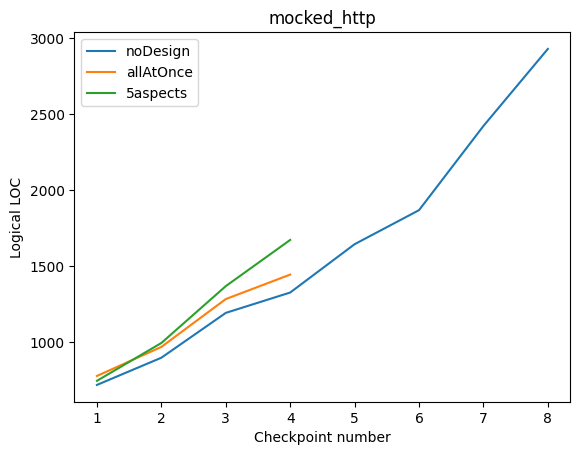

In [3]:
lloc = [[x["lloc"] for x in entry] for entry in radon_metrics]
print(lloc) 

from matplotlib import pyplot as plt 

for i, entry in enumerate(lloc): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = entry
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Logical LOC")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Functions with high CC | Max LOC function | Classes with high fan out 

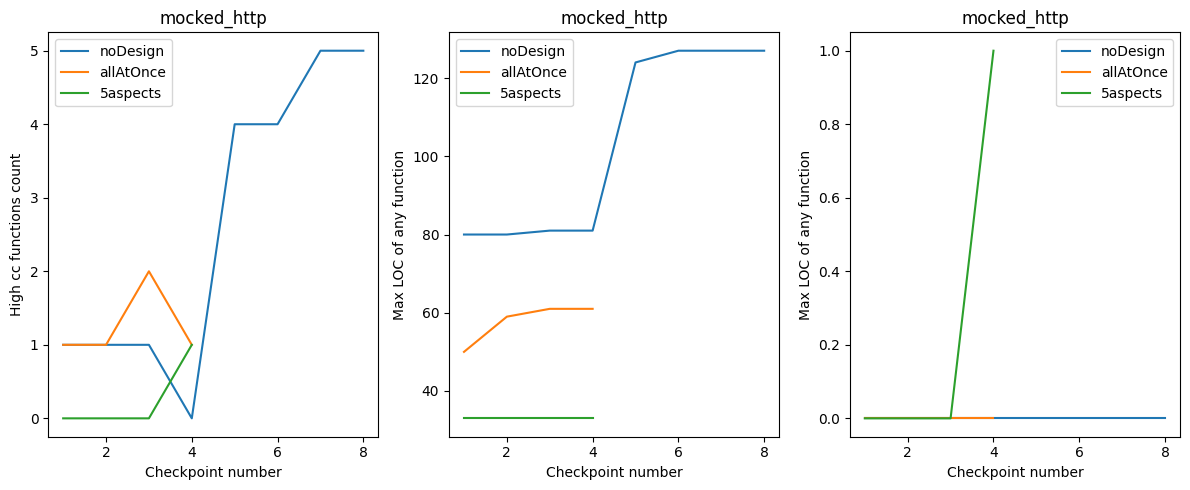

In [4]:
high_cc = [[x["high_cc_functions_count"] for x in entry] for entry in dpy_metrics]
function_max_loc = [[x["function_max_loc"] for x in entry] for entry in dpy_metrics]
high_fan_out = [[x["high_fan_out_classes_count"] for x in entry] for entry in dpy_metrics]

from matplotlib import pyplot as plt 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

for i, entry in enumerate(high_cc):
    x = range(1, len(entry) + 1) 
    y = entry
    ax1.plot(x, y, label=MODES[i])
ax1.set_xlabel("Checkpoint number")
ax1.set_ylabel("High cc functions count")
ax1.set_title(PROBLEM)
ax1.legend()

for i, entry in enumerate(function_max_loc):
    x = range(1, len(entry) + 1)
    y = entry
    ax2.plot(x, y, label=MODES[i])
ax2.set_xlabel("Checkpoint number")
ax2.set_ylabel("Max LOC of any function")
ax2.set_title(PROBLEM)
ax2.legend()

for i, entry in enumerate(high_fan_out):
    x = range(1, len(entry) + 1)
    y = entry
    ax3.plot(x, y, label=MODES[i])
ax3.set_xlabel("Checkpoint number")
ax3.set_ylabel("Max LOC of any function")
ax3.set_title(PROBLEM)
ax3.legend()

plt.tight_layout()
plt.show()

## Maintainability index (Weighted)

[[23.340860635862068, 18.96556863372848, 18.879134134921966, 18.11845682307279, 15.661847982590084, 15.975853365566406, 15.520009872760715, 16.294594918391503], [40.31756577036739, 35.063124873149846, 35.07592872367816, 33.81098058165759], [42.837678440370915, 44.777316498533935, 46.46893926056519, 45.16405285691483]]


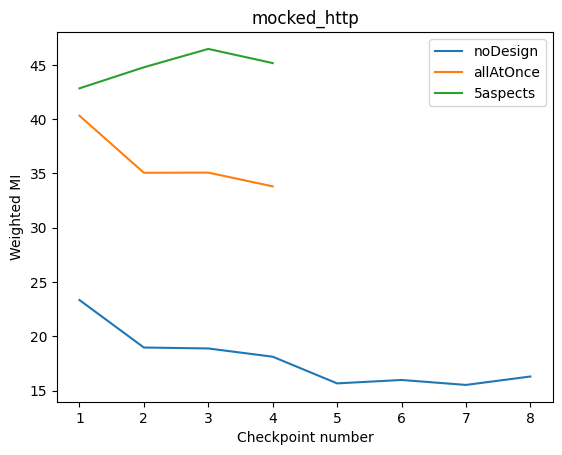

In [5]:
mi = [[x["weighted_maintainability_index"] for x in entry] for entry in radon_metrics]
print(mi) 

from matplotlib import pyplot as plt 

for i, entry in enumerate(mi): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = entry
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Weighted MI")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Duplicated lines percentage

[[0.0, 0.0, 0.0, 0.0, 0.004221388367729831, 0.003708281829419036, 0.0428979980934223, 0.04821475110763617], [0.0, 0.0, 0.005022321428571429, 0.0], [0.0, 0.0, 0.004887585532746823, 0.002366863905325444]]


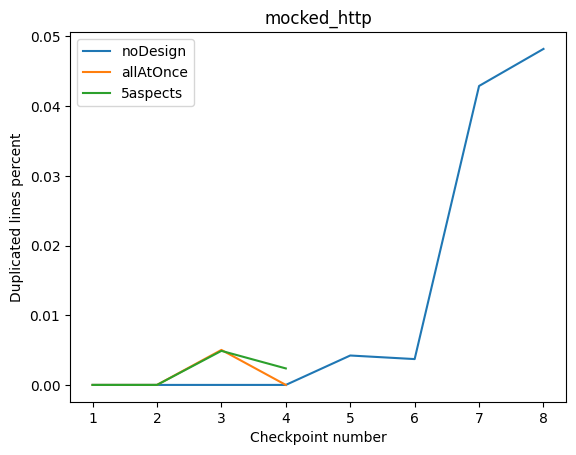

In [6]:
dup = [[x["lines"] for x in entry] for entry in jscpd_metrics]
print(dup) 

from matplotlib import pyplot as plt 

for i, entry in enumerate(dup): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = entry
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Duplicated lines percent")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Whether graph has cycles

In [7]:
for i, entry in enumerate(deps_graph_metrics): 
    print(f"{MODES[i]}: {[x["has_cycles"] for x in entry]}")

noDesign: [False, False, False, False, False, False, False, False]
allAtOnce: [False, False, False, False]
5aspects: [False, False, True, False]


## Propagation cost (and the number of modules)

[[0.34375, 0.34375, 0.2962962962962963, 0.30864197530864196, 0.328125, 0.328125, 0.31, 0.2916666666666667], [0.25443786982248523, 0.25443786982248523, 0.2109375, 0.2006172839506173], [0.27555555555555555, 0.2465277777777778, 0.17998163452708907, 0.18767313019390583]]


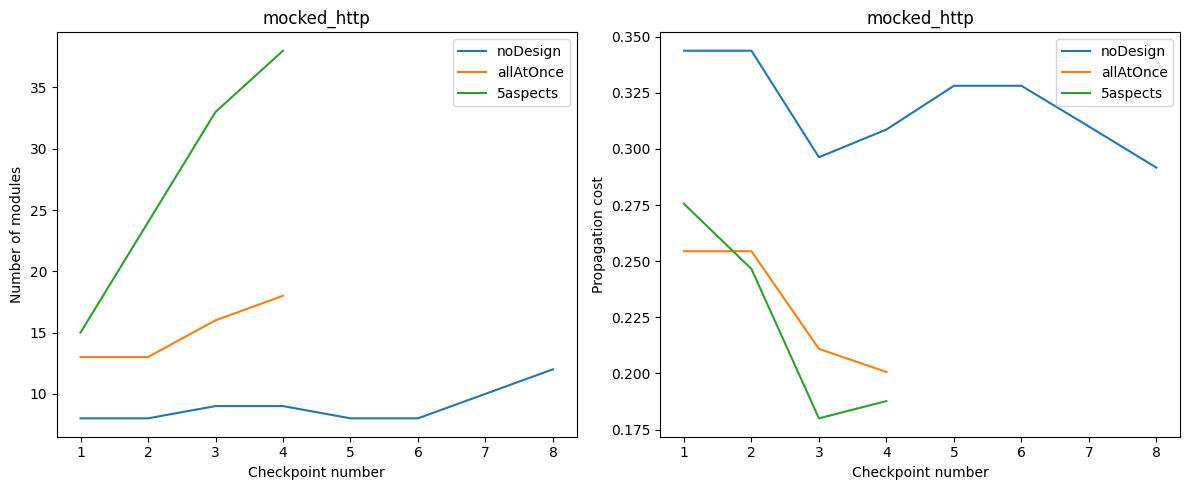

In [8]:
ns = [[x["number_of_modules"] for x in entry] for entry in deps_graph_metrics]
pc = [[x["propagation_cost"] for x in entry] for entry in deps_graph_metrics]
print(pc) 

from matplotlib import pyplot as plt 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i, entry in enumerate(ns):
    x = range(1, len(entry) + 1) 
    y = entry
    ax1.plot(x, y, label=MODES[i])
ax1.set_xlabel("Checkpoint number")
ax1.set_ylabel("Number of modules")
ax1.set_title(PROBLEM)
ax1.legend()

for i, entry in enumerate(pc):
    x = range(1, len(entry) + 1)
    y = entry
    ax2.plot(x, y, label=MODES[i])
ax2.set_xlabel("Checkpoint number")
ax2.set_ylabel("Propagation cost")
ax2.set_title(PROBLEM)
ax2.legend()

plt.tight_layout()
plt.show()

## 